In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Set a seed so you can reproduce the exact same games while testing
np.random.seed(42)

In [2]:
GAMES = 50
MAX_ROUNDS = 30 # Statistically sufficient to reach 5 points

# Shape: (50 games, 30 rounds, 2 players, 3 dice)
rolls = np.random.randint(1, 7, size=(GAMES, MAX_ROUNDS, 2, 3))

# Calculate the sum of the 3 dice for each player. 
# New Shape: (50, 30, 2)
sums = rolls.sum(axis=3)

# Create a boolean tensor for the automatic win condition (all three dice are 1s).
# New Shape: (50, 30, 2)
is_111 = np.all(rolls == 1, axis=3)

In [3]:
# 1. Base Scores via Math
# If P1 > P2: sign is 1. P1 gets 0.5 + 0.5(1) = 1.0. P2 gets 0.5 - 0.5(1) = 0.0
# If Tie: sign is 0. Both get 0.5 + 0.5(0) = 0.5
sum_diff = sums[:, :, 0] - sums[:, :, 1]
p1_score = 0.5 + 0.5 * np.sign(sum_diff)
p2_score = 0.5 - 0.5 * np.sign(sum_diff)

# 2. The 1-1-1 Rule Override via Boolean Masking
# Find any round where AT LEAST one player rolled 1-1-1
any_111 = is_111[:, :, 0] | is_111[:, :, 1]

# Directly overwrite the scores for those specific rounds using the mask
p1_score[any_111] = is_111[:, :, 0][any_111].astype(float)
p2_score[any_111] = is_111[:, :, 1][any_111].astype(float)

# Stack them back together into a single tensor: Shape (50, 30, 2)
pts = np.stack((p1_score, p2_score), axis=2)

In [8]:
# Cumulative points across rounds (axis 1)
cum_pts = np.cumsum(pts, axis=1)

# Game End Condition: Someone hits >= 5 AND it's not a tie
valid_win = (cum_pts[:, :, 0] >= 5) | (cum_pts[:, :, 1] >= 5)
not_tie = cum_pts[:, :, 0] != cum_pts[:, :, 1]
win_mask = valid_win & not_tie

# np.argmax finds the index of the FIRST round where the win condition becomes True
win_rounds = np.argmax(win_mask, axis=1)

# Extract the final scores using the winning round indices
p1_final = cum_pts[np.arange(GAMES), win_rounds, 0]
p2_final = cum_pts[np.arange(GAMES), win_rounds, 1]

# Probability calculation
p1_wins = np.sum(p1_final > p2_final)
print(f"Player 1 won {p1_wins} out of {GAMES} games.")
print(f"Probability of Player 1 winning: {p1_wins / GAMES:.2f}")

Player 1 won 26 out of 50 games.
Probability of Player 1 winning: 0.52


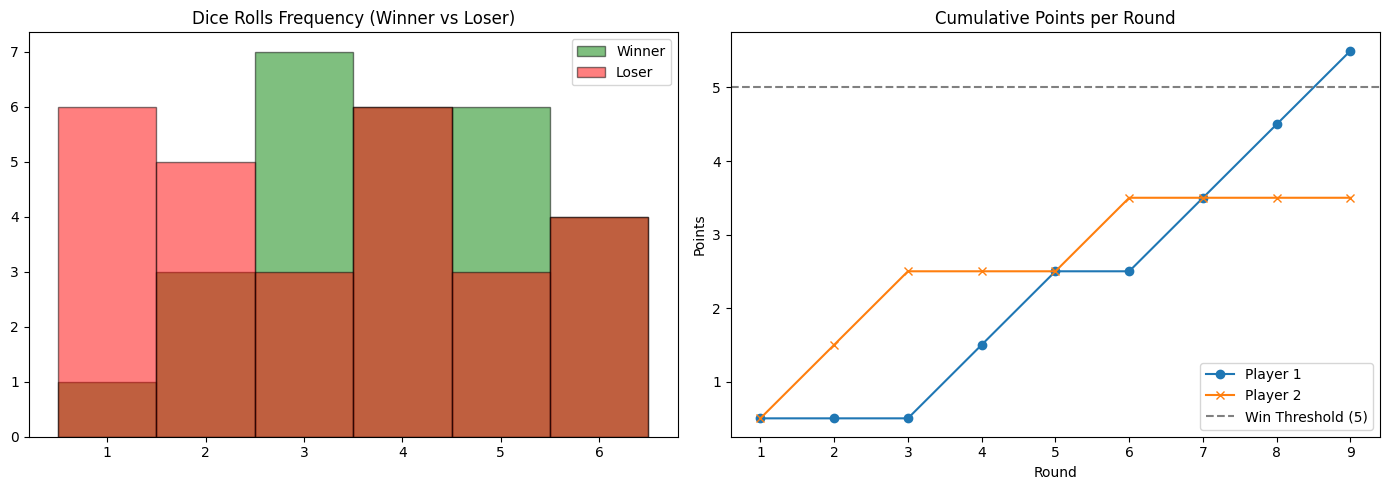

In [9]:
game_idx = 0
rounds_played = win_rounds[game_idx] + 1 

# Extract data for this specific game
game_rolls = rolls[game_idx, :rounds_played] 
game_cum_pts = cum_pts[game_idx, :rounds_played] 

winner_idx = 0 if p1_final[game_idx] > p2_final[game_idx] else 1
loser_idx = 1 - winner_idx

winner_rolls = game_rolls[:, winner_idx, :].flatten()
loser_rolls = game_rolls[:, loser_idx, :].flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(winner_rolls, bins=np.arange(1, 8)-0.5, alpha=0.5, label='Winner', color='green', edgecolor='black')
axes[0].hist(loser_rolls, bins=np.arange(1, 8)-0.5, alpha=0.5, label='Loser', color='red', edgecolor='black')
axes[0].set_title('Dice Rolls Frequency (Winner vs Loser)')
axes[0].set_xticks(range(1, 7))
axes[0].legend()

# Line chart
axes[1].plot(range(1, rounds_played + 1), game_cum_pts[:, 0], marker='o', label='Player 1')
axes[1].plot(range(1, rounds_played + 1), game_cum_pts[:, 1], marker='x', label='Player 2')
axes[1].axhline(y=5, color='gray', linestyle='--', label='Win Threshold (5)')
axes[1].set_title('Cumulative Points per Round')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Points')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# Flatten rolls and sums
all_individual_rolls = rolls.flatten()
all_sums = sums.flatten()

# Chi-Square Test for Uniformity
observed_freq, _ = np.histogram(all_individual_rolls, bins=np.arange(1, 8))
expected_freq = np.full(6, len(all_individual_rolls) / 6)
chi_stat, chi_p = stats.chisquare(f_obs=observed_freq, f_exp=expected_freq)

print("--- Individual Rolls (Uniformity) ---")
print(f"Chi-Square p-value: {chi_p:.4f}")

# Shapiro-Wilk Test for Normality
# Sample 1000 to avoid large N issues with Shapiro
sample_sums = np.random.choice(all_sums, 1000, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample_sums)

print("\n--- Sum of 3 Dice (Normality) ---")
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")

--- Individual Rolls (Uniformity) ---
Chi-Square p-value: 0.8127

--- Sum of 3 Dice (Normality) ---
Shapiro-Wilk p-value: 0.0000
